# 6. Federated Learning CNN2D - Salinas (FedAvg)

X_train, 30 istemciye (client) IID olarak eşit bölünür.  
Her round'da tüm istemciler 5 epoch lokal eğitim yapar, ardından server ağırlıkları FedAvg ile birleştirir.  
**50 round, 30 client, local E=5, IID partition, FedAvg aggregation.**

### Adım 1: Google Colab ve Google Drive Hazırlığı

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("✅ Google Colab ortamı algılandı. Drive başarıyla bağlandı.")
except ModuleNotFoundError:
    IN_COLAB = False
    print("💻 Lokal ortam algılandı.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Colab ortamı algılandı. Drive başarıyla bağlandı.


### Adım 2: Gerekli Kütüphanelerin Yüklenmesi

In [2]:
if IN_COLAB:
    !pip install -q torch torchvision scikit-learn seaborn matplotlib

import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


### Adım 3: Verilerin Yüklenmesi

In [3]:
if IN_COLAB:
    PROCESSED_DIR = '/content/drive/MyDrive/datasets/processed'
else:
    PROCESSED_DIR = './datasets/processed'

dataset_prefix = 'salinas_gauss0.5_pca30'

X_train = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_X_train.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_y_train.npy'))
X_test  = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_X_test.npy'))
y_test  = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_y_test.npy'))

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Sınıf sayısı: {len(np.unique(y_train))}")

X_train: (5412, 15, 15, 30), X_test: (48717, 15, 15, 30)
Sınıf sayısı: 16


### Adım 4: Federated Kurulum — IID Partition

X_train, 30 istemciye rastgele eşit bölünür (IID).  
Her istemci yaklaşık `len(X_train) / NUM_CLIENTS` örnek alır.

In [4]:
NUM_CLIENTS   = 30
NUM_ROUNDS    = 50
LOCAL_EPOCHS  = 5
BATCH_SIZE    = 64
LEARNING_RATE = 0.001

num_classes = len(np.unique(y_train))

# IID: rastgele karıştır, eşit böl
rng  = np.random.default_rng(42)
idx  = rng.permutation(len(X_train))
client_indices = np.array_split(idx, NUM_CLIENTS)

print(f"Her istemcideki ortalama örnek: {len(X_train) // NUM_CLIENTS}")
print(f"İstemci 0 örnek sayısı: {len(client_indices[0])}")

Her istemcideki ortalama örnek: 180
İstemci 0 örnek sayısı: 181


### Adım 5: Model Tanımı

Supervised CNN ile aynı mimari kullanılır.

In [5]:
class HSI_CNN(nn.Module):
    def __init__(self, num_classes, input_channels=30):
        super(HSI_CNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.fc_block = nn.Sequential(
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.flatten(1)
        return self.fc_block(x)


def make_model():
    return HSI_CNN(num_classes=num_classes).to(device)


def to_tensor_X(X):
    """(N,H,W,C) -> (N,C,H,W) float32 tensor"""
    return torch.tensor(np.transpose(X, (0, 3, 1, 2)), dtype=torch.float32)


print(f"Model parametreleri: {sum(p.numel() for p in make_model().parameters()):,}")

Model parametreleri: 390,864


### Adım 6: FedAvg Yardımcı Fonksiyonları

In [6]:
def local_train(global_weights, client_X, client_y):
    """Bir istemcinin lokal eğitimi; güncellenmiş ağırlıkları döndürür."""
    model = make_model()
    model.load_state_dict(copy.deepcopy(global_weights))
    model.train()

    X_t = to_tensor_X(client_X)
    y_t = torch.tensor(client_y - 1, dtype=torch.long)  # 0-indexed
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH_SIZE, shuffle=True)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    for _ in range(LOCAL_EPOCHS):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            criterion(model(inputs), labels).backward()
            optimizer.step()

    return model.state_dict(), len(client_X)


def fedavg(client_updates):
    """FedAvg: veri boyutuna göre ağırlıklı ortalama."""
    total = sum(n for _, n in client_updates)
    avg   = copy.deepcopy(client_updates[0][0])
    for key in avg:
        avg[key] = sum(
            w[key].float() * (n / total)
            for w, n in client_updates
        )
    return avg


def evaluate_global(global_weights, X, y):
    """Global modeli test setinde değerlendirir."""
    model = make_model()
    model.load_state_dict(global_weights)
    model.eval()

    X_t    = to_tensor_X(X)
    loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
    preds  = []
    with torch.no_grad():
        for (inputs,) in loader:
            preds.append(model(inputs.to(device)).argmax(1).cpu().numpy())
    preds = np.concatenate(preds) + 1  # 1-indexed

    return {
        'Accuracy':  accuracy_score(y, preds) * 100,
        'Precision': precision_score(y, preds, average='macro', zero_division=0) * 100,
        'Recall':    recall_score(y, preds, average='macro', zero_division=0) * 100,
        'F1-Score':  f1_score(y, preds, average='macro', zero_division=0) * 100,
        'Kappa':     cohen_kappa_score(y, preds) * 100,
    }, preds

### Adım 7: FedAvg Eğitim Döngüsü

Her round:
1. Global model tüm 30 istemciye gönderilir
2. Her istemci 5 epoch lokal eğitim yapar
3. Server ağırlıkları FedAvg ile birleştirir
4. Global model test setinde değerlendirilir

In [7]:
global_model  = make_model()
global_weights = global_model.state_dict()

round_results = []

for rnd in range(1, NUM_ROUNDS + 1):
    # Tüm istemciler lokal eğitim yapar
    client_updates = []
    for cid in range(NUM_CLIENTS):
        cidx     = client_indices[cid]
        cX, cy   = X_train[cidx], y_train[cidx]
        w, n     = local_train(global_weights, cX, cy)
        client_updates.append((w, n))

    # FedAvg aggregation
    global_weights = fedavg(client_updates)

    # Her 5 round'da veya son round'da evaluate et
    if rnd % 5 == 0 or rnd == 1:
        metrics, _ = evaluate_global(global_weights, X_test, y_test)
        metrics['Round'] = rnd
        round_results.append(metrics)
        print(f"Round {rnd:3d} | Acc: %{metrics['Accuracy']:.2f} | "
              f"F1: %{metrics['F1-Score']:.2f} | Kappa: %{metrics['Kappa']:.2f}")

print("\nEğitim tamamlandı.")

Round   1 | Acc: %27.54 | F1: %8.96 | Kappa: %13.70
Round   5 | Acc: %97.06 | F1: %98.60 | Kappa: %96.74
Round  10 | Acc: %97.96 | F1: %99.06 | Kappa: %97.73
Round  15 | Acc: %98.47 | F1: %99.27 | Kappa: %98.30
Round  20 | Acc: %98.98 | F1: %99.48 | Kappa: %98.87
Round  25 | Acc: %99.62 | F1: %99.70 | Kappa: %99.58
Round  30 | Acc: %99.38 | F1: %99.67 | Kappa: %99.31
Round  35 | Acc: %99.74 | F1: %99.80 | Kappa: %99.71
Round  40 | Acc: %99.89 | F1: %99.87 | Kappa: %99.87
Round  45 | Acc: %99.88 | F1: %99.89 | Kappa: %99.87
Round  50 | Acc: %99.90 | F1: %99.88 | Kappa: %99.89

Eğitim tamamlandı.


### Adım 8: Round Sonuçları Tablosu

In [8]:
df_rounds = pd.DataFrame(round_results).set_index('Round')
display(df_rounds[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Kappa']].round(2))

,Accuracy,Precision,Recall,F1-Score,Kappa
Round,,,,,
1,27.54,17.67,12.60,8.96,13.70
5,97.06,98.51,98.73,98.60,96.74
10,97.96,98.98,99.19,99.06,97.73
15,98.47,99.20,99.37,99.27,98.30
20,98.98,99.42,99.56,99.48,98.87
25,99.62,99.66,99.74,99.70,99.58
30,99.38,99.63,99.71,99.67,99.31
35,99.74,99.79,99.82,99.80,99.71
40,99.89,99.87,99.86,99.87,99.87


### Adım 9: Final Değerlendirme (50. Round)

In [9]:
final_metrics, final_preds = evaluate_global(global_weights, X_test, y_test)

print("=== Final Model (Round 50) ===")
for k, v in final_metrics.items():
    print(f"  {k}: %{v:.2f}")

=== Final Model (Round 50) ===
  Accuracy: %99.90
  Precision: %99.89
  Recall: %99.88
  F1-Score: %99.88
  Kappa: %99.89


### Adım 10: Görselleştirme

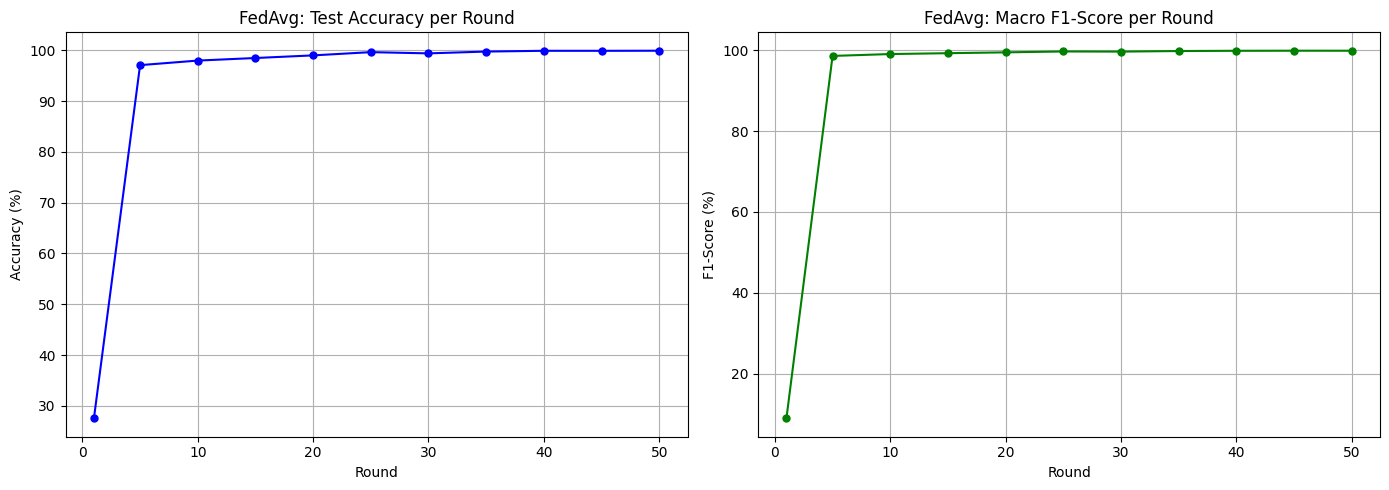

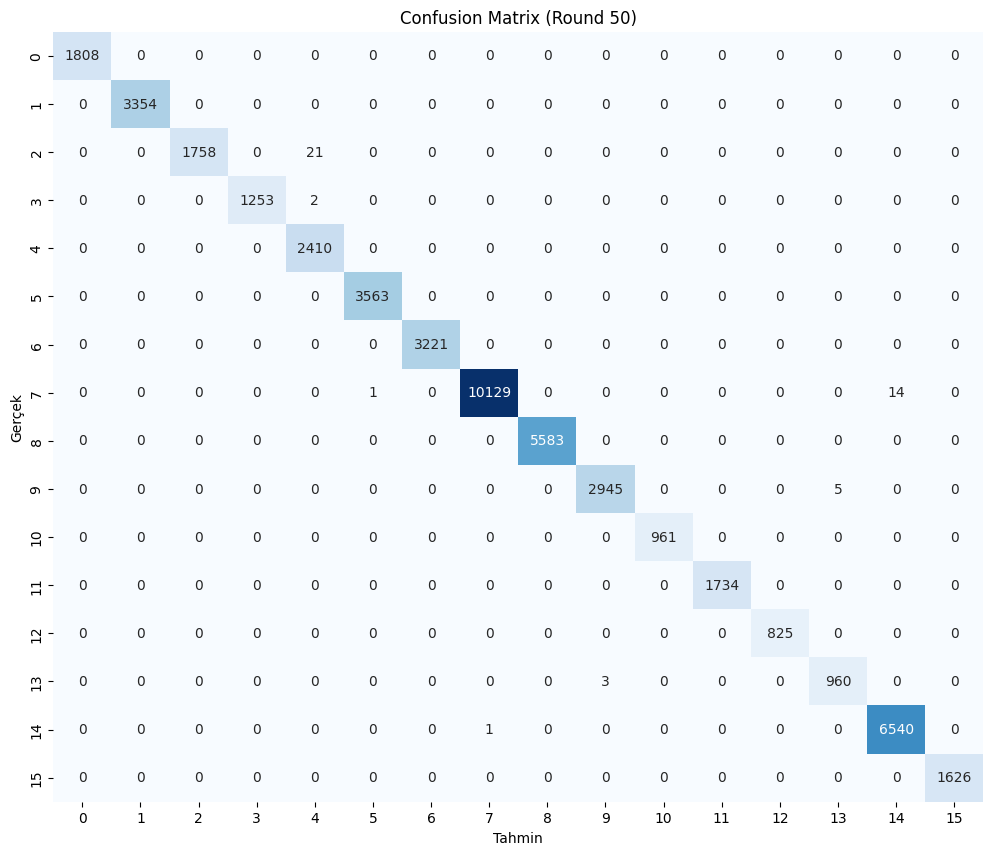

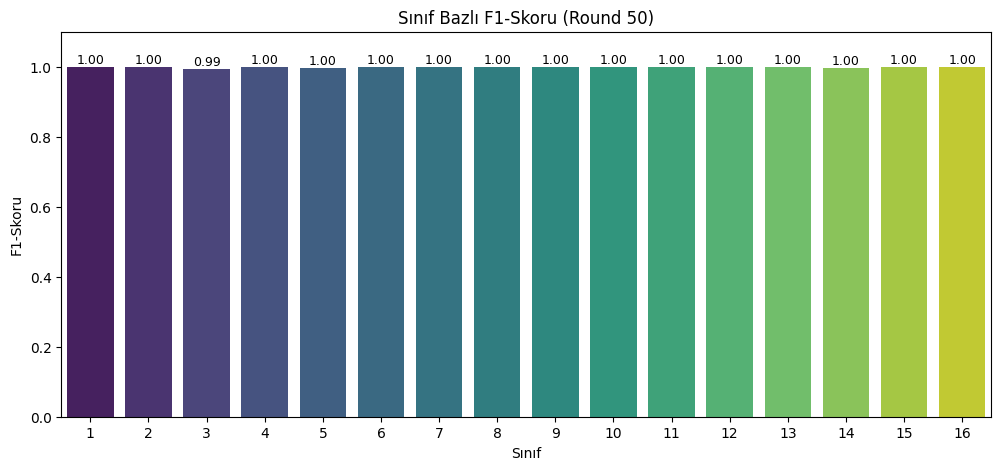

In [10]:
rounds_x    = df_rounds.index.tolist()
accuracies  = df_rounds['Accuracy'].tolist()
f1_macro    = df_rounds['F1-Score'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds_x, accuracies, 'b-o', markersize=5)
axes[0].set_title('FedAvg: Test Accuracy per Round')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy (%)')
axes[0].grid(True)

axes[1].plot(rounds_x, f1_macro, 'g-o', markersize=5)
axes[1].set_title('FedAvg: Macro F1-Score per Round')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('F1-Score (%)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Round 50)')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.show()

# Sınıf bazlı F1
report = classification_report(y_test, final_preds, output_dict=True, zero_division=0)
classes   = [k for k in report.keys() if k.isdigit()]
f1_scores = [report[k]['f1-score'] for k in classes]

plt.figure(figsize=(12, 5))
sns.barplot(x=classes, y=f1_scores, hue=classes, palette='viridis', dodge=False, legend=False)
plt.title('Sınıf Bazlı F1-Skoru (Round 50)')
plt.xlabel('Sınıf')
plt.ylabel('F1-Skoru')
plt.ylim(0, 1.1)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.show()

### Adım 11: Model Kaydı

In [11]:
import shutil

final_model = make_model()
final_model.load_state_dict(global_weights)

model_save_path = f'federated_cnn_model_{dataset_prefix}.pth'
torch.save(final_model.state_dict(), model_save_path)
print(f"Model kaydedildi: {model_save_path}")

if IN_COLAB:
    drive_save_path = f'/content/drive/MyDrive/models/{model_save_path}'
    os.makedirs(os.path.dirname(drive_save_path), exist_ok=True)
    shutil.copy(model_save_path, drive_save_path)
    print(f"Drive'a kopyalandı: {drive_save_path}")

Model kaydedildi: federated_cnn_model_salinas_gauss0.5_pca30.pth
Drive'a kopyalandı: /content/drive/MyDrive/models/federated_cnn_model_salinas_gauss0.5_pca30.pth
